<a href="https://colab.research.google.com/github/SohanKumar56/23102A0056_RPROGRAMMING/blob/main/LAB7_R_23102A0056_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install/load packages

In [1]:
install.packages(c(
  "readxl", "dplyr", "lubridate", "ggplot2",
  "cluster", "factoextra", "randomForest",
  "e1071", "pROC", "caret", "plotly",
  "scales"
))

library(readxl)
library(dplyr)
library(lubridate)
library(ggplot2)
library(cluster)
library(factoextra)
library(randomForest)
library(e1071)
library(pROC)
library(caret)
library(plotly)
library(scales)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘future’, ‘globals’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘diagram’, ‘lava’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘showtextdb’, ‘corrplot’, ‘prodlim’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘irlba’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘showtext’, ‘sysfonts’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘lazyeval’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’, ‘proxy’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘crosstalk’



Attaching pack

2. Upload/read Excel file

In [2]:
library(readxl)

data <- read_excel("/content/Online Retail.xlsx")

head(data)
dim(data)
str(data)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


[1] 541909      8

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


3. Data preprocessing

In [4]:
data <- data %>%
  filter(!is.na(CustomerID)) %>%
  filter(Quantity > 0) %>%
  filter(UnitPrice > 0) %>%
  mutate(
    CustomerID = as.character(CustomerID),
    InvoiceDate = as.POSIXct(InvoiceDate),
    TotalAmount = Quantity * UnitPrice
  )

# Remove cancelled invoices
data <- data %>%
  filter(!grepl("^C", InvoiceNo))

summary(data)

     InvoiceNo          StockCode         Description        Quantity       
 Length   :397884   Length   :397884   Length   :397884   Min.   :    1.00  
 N.unique : 18532   N.unique :  3665   N.unique :  3866   1st Qu.:    2.00  
 N.blank  :     0   N.blank  :     0   N.blank  :     0   Median :    6.00  
 Min.nchar:     6   Min.nchar:     1   Min.nchar:     6   Mean   :   12.99  
 Max.nchar:     6   Max.nchar:    12   Max.nchar:    35   3rd Qu.:   12.00  
                                                          Max.   :80995.00  
  InvoiceDate                    UnitPrice            CustomerID    
 Min.   :2010-12-01 08:26:00   Min.   :   0.001   Length   :397884  
 1st Qu.:2011-04-07 11:12:00   1st Qu.:   1.250   N.unique :  4338  
 Median :2011-07-31 14:39:00   Median :   1.950   N.blank  :     0  
 Mean   :2011-07-10 23:41:23   Mean   :   3.116   Min.nchar:     5  
 3rd Qu.:2011-10-20 14:33:00   3rd Qu.:   3.750   Max.nchar:     5  
 Max.   :2011-12-09 12:50:00   Max.   :8142.750

4. Create customer-level RFM features

In [5]:
reference_date <- max(data$InvoiceDate) + days(1)

rfm <- data %>%
  group_by(CustomerID) %>%
  summarise(
    Recency = as.numeric(
      difftime(reference_date, max(InvoiceDate), units = "days")
    ),
    Frequency = n_distinct(InvoiceNo),
    Monetary = sum(TotalAmount),
    AvgTransactionValue = mean(TotalAmount),
    QuantityPurchased = sum(Quantity),
    PurchaseFrequency = n() / n_distinct(InvoiceNo)
  )

head(rfm)
summary(rfm)

CustomerID,Recency,Frequency,Monetary,AvgTransactionValue,QuantityPurchased,PurchaseFrequency
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
12346,326.117361,1,77183.60,77183.60000,74215,1.000
12347,2.873611,7,4310.00,23.68132,2458,26.000
12348,75.984028,4,1797.24,57.97548,2341,7.750
12349,19.124306,1,1757.55,24.07603,631,73.000
12350,310.867361,1,334.40,19.67059,197,17.000
12352,36.925694,8,2506.04,29.48282,536,10.625


     CustomerID      Recency         Frequency          Monetary        
 Length   :4338   Min.   :  1.00   Min.   :  1.000   Min.   :     3.75  
 N.unique :4338   1st Qu.: 18.07   1st Qu.:  1.000   1st Qu.:   307.42  
 N.blank  :   0   Median : 51.09   Median :  2.000   Median :   674.49  
 Min.nchar:   5   Mean   : 93.05   Mean   :  4.272   Mean   :  2054.27  
 Max.nchar:   5   3rd Qu.:142.73   3rd Qu.:  5.000   3rd Qu.:  1661.74  
                  Max.   :374.12   Max.   :209.000   Max.   :280206.02  
 AvgTransactionValue QuantityPurchased  PurchaseFrequency
 Min.   :    2.101   Min.   :     1.0   Min.   :  1.00   
 1st Qu.:   12.365   1st Qu.:   160.0   1st Qu.:  9.50   
 Median :   17.723   Median :   379.0   Median : 17.00   
 Mean   :   68.351   Mean   :  1191.3   Mean   : 22.19   
 3rd Qu.:   24.858   3rd Qu.:   992.8   3rd Qu.: 28.25   
 Max.   :77183.600   Max.   :196915.0   Max.   :300.65   

5. Handle outliers using log transformation


In [6]:
rfm_scaled <- rfm %>%
  mutate(
    Recency = log1p(Recency),
    Frequency = log1p(Frequency),
    Monetary = log1p(Monetary),
    AvgTransactionValue = log1p(AvgTransactionValue),
    QuantityPurchased = log1p(QuantityPurchased),
    PurchaseFrequency = log1p(PurchaseFrequency)
  )

features <- rfm_scaled %>%
  select(-CustomerID)

features_scaled <- scale(features)

head(features_scaled)

Recency,Frequency,Monetary,AvgTransactionValue,QuantityPurchased,PurchaseFrequency
1.4789643,-0.9551042,3.7057976,9.64387421,3.8162133,-2.59928416
-1.9142605,1.0743013,1.4116807,0.26078218,1.3293320,0.56584704
0.3723584,0.3862599,0.7164063,1.27637259,1.2937504,-0.80443408
-0.6538931,-0.9551042,0.6986589,0.27928005,0.3376956,1.79195349
1.4424469,-0.9551042,-0.6188909,0.05402676,-0.5094249,0.07276088
-0.1691716,1.2467247,0.9806400,0.50692411,0.2188037,-0.45893487


6. Elbow Method

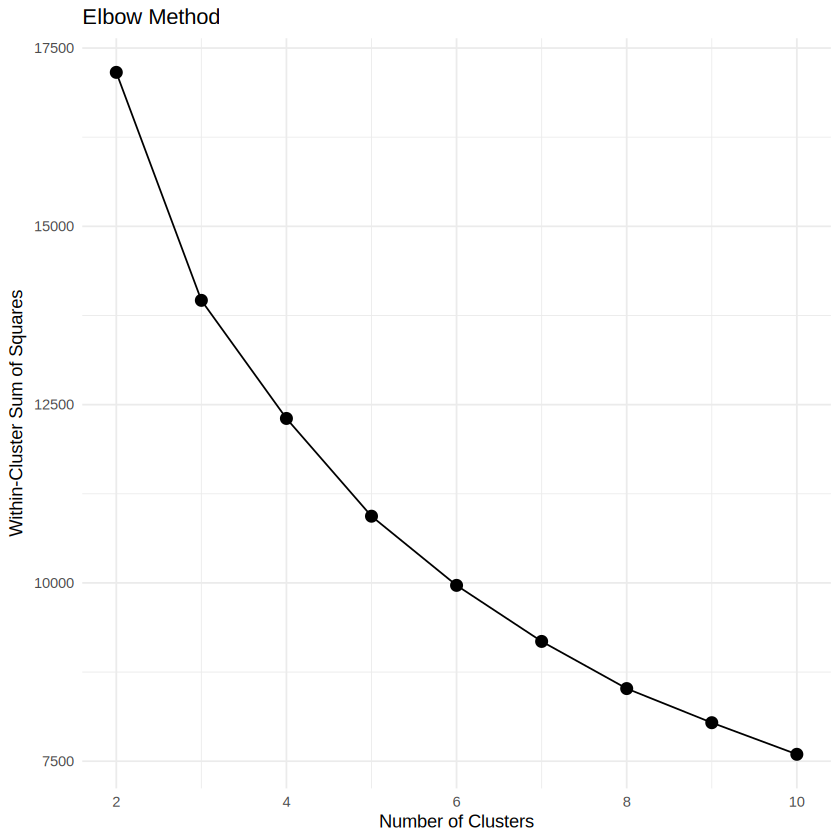

In [7]:
set.seed(42)

wss <- sapply(2:10, function(k) {
  kmeans(features_scaled, centers = k, nstart = 10)$tot.withinss
})

elbow_data <- data.frame(
  K = 2:10,
  WSS = wss
)

ggplot(elbow_data, aes(x = K, y = WSS)) +
  geom_line() +
  geom_point(size = 3) +
  labs(
    title = "Elbow Method",
    x = "Number of Clusters",
    y = "Within-Cluster Sum of Squares"
  ) +
  theme_minimal()

In [9]:
optimal_k <- 4

7. K-Means clustering

In [10]:
set.seed(42)

kmeans_model <- kmeans(
  features_scaled,
  centers = optimal_k,
  nstart = 25
)

rfm$Cluster <- factor(kmeans_model$cluster)

table(rfm$Cluster)


   1    2    3    4 
1063 1187  369 1719 

8. Silhouette Score

In [11]:
sil <- silhouette(
  kmeans_model$cluster,
  dist(features_scaled)
)

mean_silhouette <- mean(sil[, 3])

cat("Average Silhouette Score:",
    round(mean_silhouette, 4))

Average Silhouette Score: 0.2349

  cluster size ave.sil.width
1       1 1063          0.26
2       2 1187          0.28
3       3  369          0.12
4       4 1719          0.21


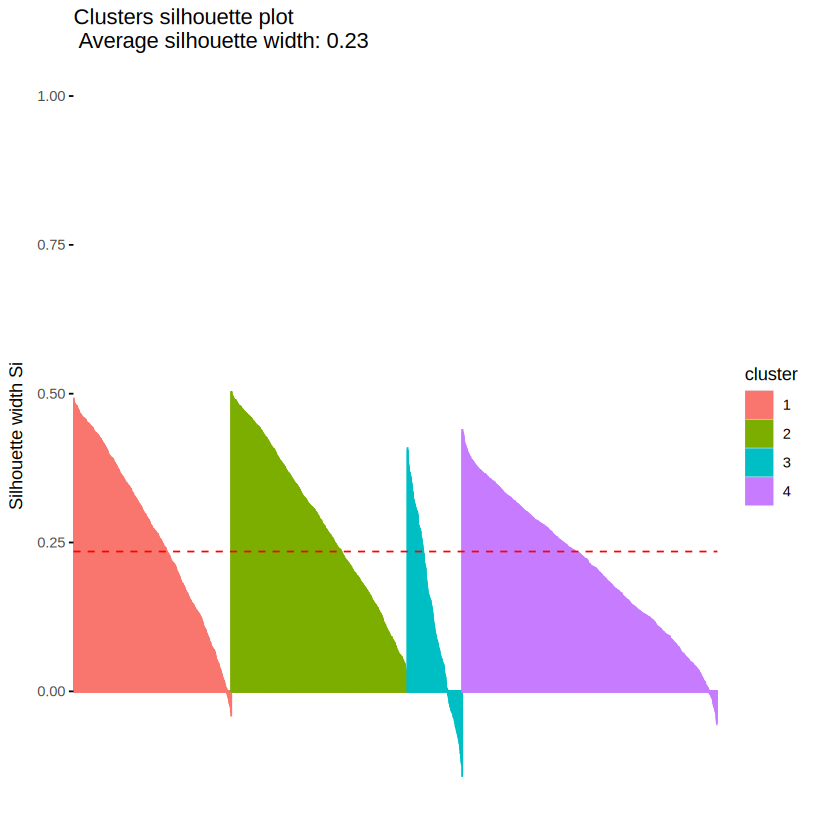

In [12]:
fviz_silhouette(sil)

9. Hierarchical Clustering + Dendrogram

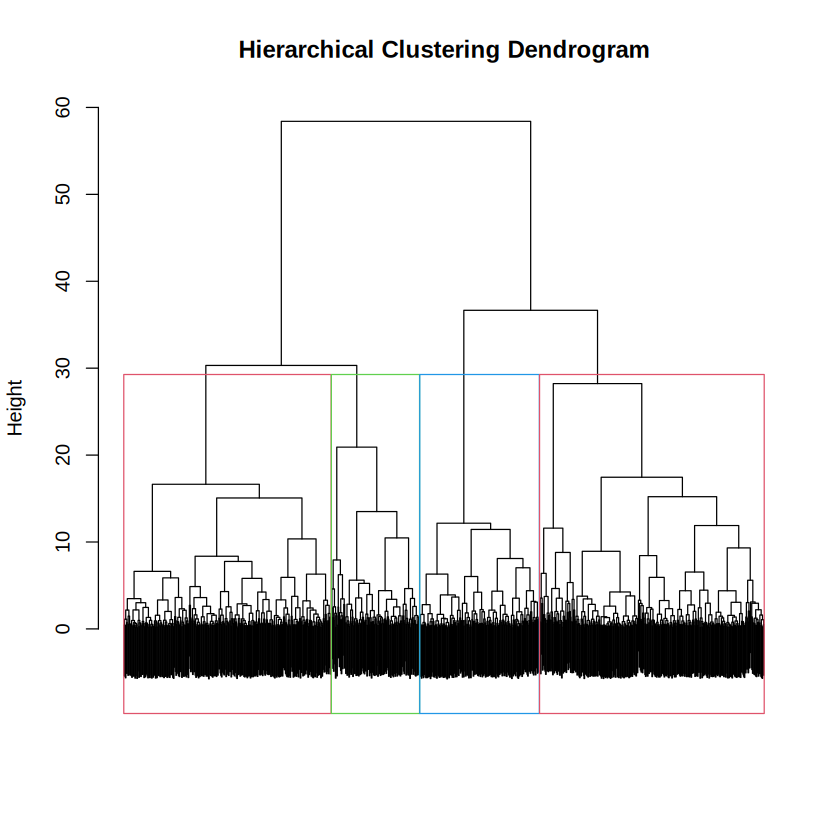

In [13]:
set.seed(42)

sample_size <- min(1000, nrow(features_scaled))

sample_indices <- sample(
  1:nrow(features_scaled),
  sample_size
)

sample_data <- features_scaled[sample_indices, ]

distance_matrix <- dist(sample_data)

hc <- hclust(
  distance_matrix,
  method = "ward.D2"
)

plot(
  hc,
  labels = FALSE,
  main = "Hierarchical Clustering Dendrogram",
  xlab = "",
  sub = ""
)

rect.hclust(
  hc,
  k = optimal_k,
  border = 2:optimal_k
)

10. PCA

In [14]:
pca <- prcomp(
  features_scaled,
  center = TRUE,
  scale. = FALSE
)

summary(pca)

Importance of components:
                          PC1    PC2    PC3     PC4     PC5     PC6
Standard deviation     1.7713 1.2893 0.8479 0.61886 0.30657 0.06576
Proportion of Variance 0.5229 0.2771 0.1198 0.06383 0.01566 0.00072
Cumulative Proportion  0.5229 0.8000 0.9198 0.98361 0.99928 1.00000

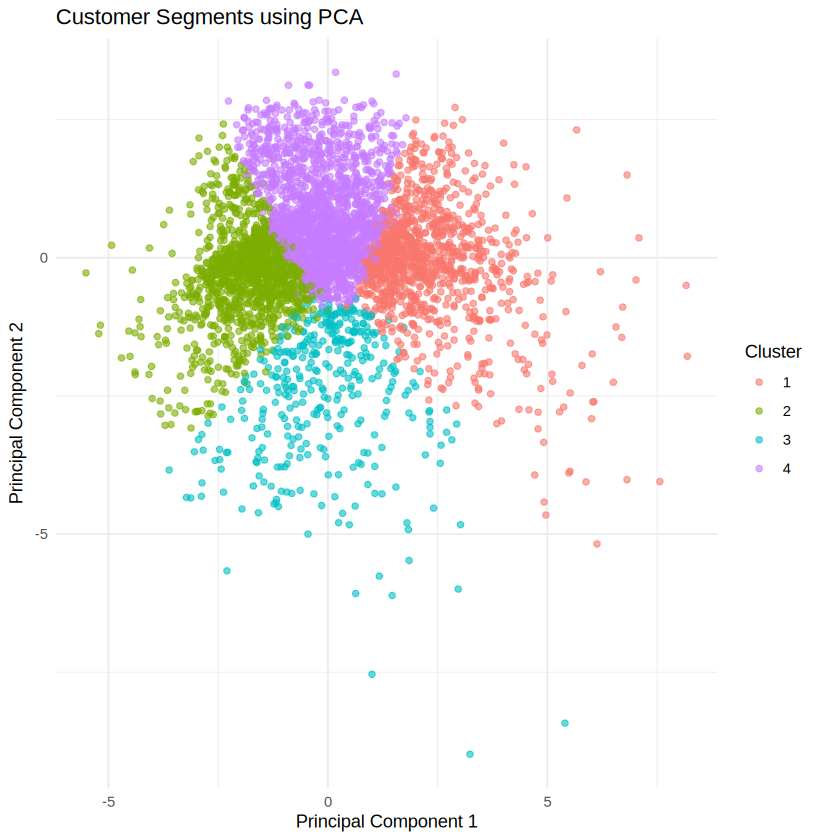

In [15]:
pca_data <- data.frame(
  PC1 = pca$x[, 1],
  PC2 = pca$x[, 2],
  Cluster = rfm$Cluster
)

ggplot(
  pca_data,
  aes(x = PC1, y = PC2, color = Cluster)
) +
  geom_point(alpha = 0.6) +
  labs(
    title = "Customer Segments using PCA",
    x = "Principal Component 1",
    y = "Principal Component 2"
  ) +
  theme_minimal()

11. Cluster profiling

In [16]:
cluster_profile <- rfm %>%
  group_by(Cluster) %>%
  summarise(
    Customers = n(),
    AvgRecency = mean(Recency),
    AvgFrequency = mean(Frequency),
    AvgMonetary = mean(Monetary),
    AvgTransactionValue = mean(AvgTransactionValue),
    AvgQuantity = mean(QuantityPurchased),
    AvgPurchaseFrequency = mean(PurchaseFrequency)
  )

cluster_profile

Cluster,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgTransactionValue,AvgQuantity,AvgPurchaseFrequency
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1063,21.94426,10.984008,6000.6693,29.73283,3456.9567,23.810219
2,1187,175.22796,1.406066,240.1819,21.03048,127.1651,10.809628
3,369,99.85480,2.951220,2293.8819,583.45193,1335.5827,5.391841
4,1719,78.81278,2.383944,815.1007,14.33482,494.0617,32.652757


12. Create high-value customer target

In [17]:
high_value_cluster <- cluster_profile$Cluster[
  which.max(cluster_profile$AvgMonetary)
]

high_value_cluster

[1] 1
Levels: 1 2 3 4

In [18]:
rfm$HighValue <- ifelse(
  rfm$Cluster == high_value_cluster,
  "Yes",
  "No"
)

rfm$HighValue <- factor(
  rfm$HighValue,
  levels = c("No", "Yes")
)

table(rfm$HighValue)


  No  Yes 
3275 1063 

13. Train/test split


In [19]:
set.seed(42)

train_index <- createDataPartition(
  rfm$HighValue,
  p = 0.8,
  list = FALSE
)

train <- rfm_scaled[train_index, ]
test <- rfm_scaled[-train_index, ]

train$HighValue <- rfm$HighValue[train_index]
test$HighValue <- rfm$HighValue[-train_index]

14. Random Forest

In [20]:
set.seed(42)

rf_model <- randomForest(
  HighValue ~ . - CustomerID,
  data = train,
  ntree = 300,
  importance = TRUE
)

rf_pred <- predict(
  rf_model,
  newdata = test
)

confusionMatrix(
  rf_pred,
  test$HighValue,
  positive = "Yes"
)

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  649   8
       Yes   6 204
                                          
               Accuracy : 0.9839          
                 95% CI : (0.9731, 0.9911)
    No Information Rate : 0.7555          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9562          
                                          
 Mcnemar's Test P-Value : 0.7893          
                                          
            Sensitivity : 0.9623          
            Specificity : 0.9908          
         Pos Pred Value : 0.9714          
         Neg Pred Value : 0.9878          
             Prevalence : 0.2445          
         Detection Rate : 0.2353          
   Detection Prevalence : 0.2422          
      Balanced Accuracy : 0.9766          
                                          
       'Positive' Class : Yes             
                              

15. Random Forest feature importance

,No,Yes,MeanDecreaseAccuracy,MeanDecreaseGini
Recency,32.05771,53.95202,61.17440,154.39586
Frequency,22.89944,52.25469,53.18989,434.34028
Monetary,15.22835,25.48766,28.74165,348.58762
AvgTransactionValue,25.19641,21.87261,33.69066,54.51834
QuantityPurchased,15.81191,23.53471,27.85916,229.80906
PurchaseFrequency,25.50256,28.50572,39.82419,63.53025


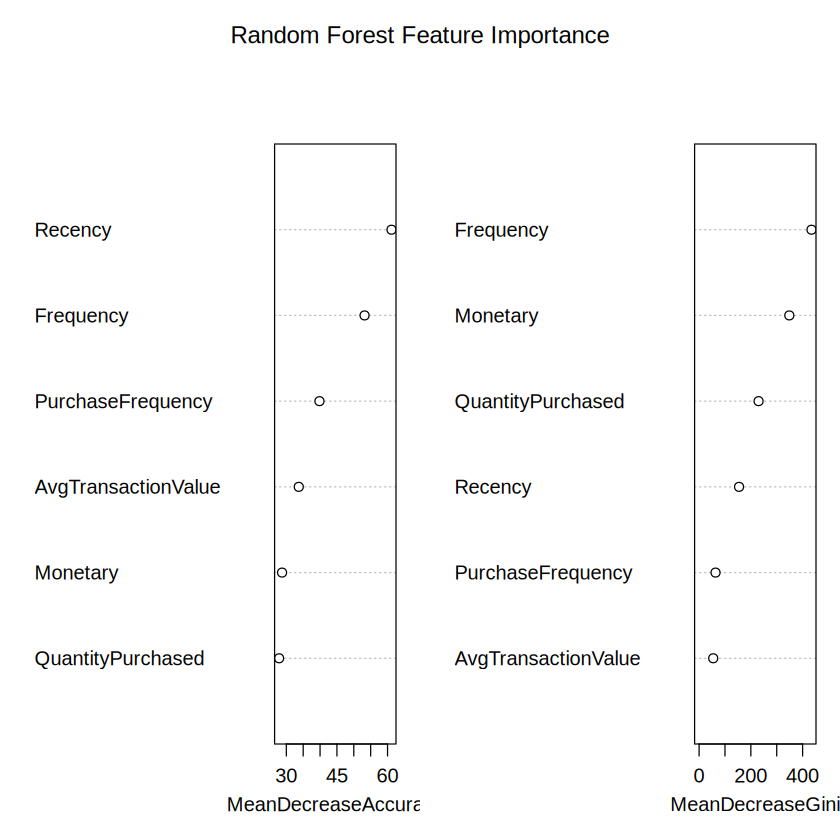

In [21]:
importance(rf_model)

varImpPlot(
  rf_model,
  main = "Random Forest Feature Importance"
)

16. SVM

In [27]:
svm_model <- svm(
  HighValue ~ . ,
  data = train %>% select(-CustomerID),
  kernel = "radial",
  probability = TRUE
)

svm_pred <- predict(
  svm_model,
  newdata = test %>% select(-CustomerID)
)

confusionMatrix(
  svm_pred,
  test$HighValue,
  positive = "Yes"
)

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  652   2
       Yes   3 210
                                          
               Accuracy : 0.9942          
                 95% CI : (0.9866, 0.9981)
    No Information Rate : 0.7555          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9844          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.9906          
            Specificity : 0.9954          
         Pos Pred Value : 0.9859          
         Neg Pred Value : 0.9969          
             Prevalence : 0.2445          
         Detection Rate : 0.2422          
   Detection Prevalence : 0.2457          
      Balanced Accuracy : 0.9930          
                                          
       'Positive' Class : Yes             
                              

17. ROC-AUC

In [23]:
rf_prob <- predict(
  rf_model,
  newdata = test,
  type = "prob"
)[, "Yes"]

rf_roc <- roc(
  test$HighValue,
  rf_prob,
  levels = c("No", "Yes")
)

auc(rf_roc)

Setting direction: controls < cases



Area under the curve: 0.9987

In [28]:
svm_prob <- attr(
  predict(
    svm_model,
    newdata = test %>% select(-CustomerID),
    probability = TRUE
  ),
  "probabilities"
)[, "Yes"]

svm_roc <- roc(
  test$HighValue,
  svm_prob,
  levels = c("No", "Yes")
)

auc(svm_roc)

Setting direction: controls < cases



Area under the curve: 0.9999

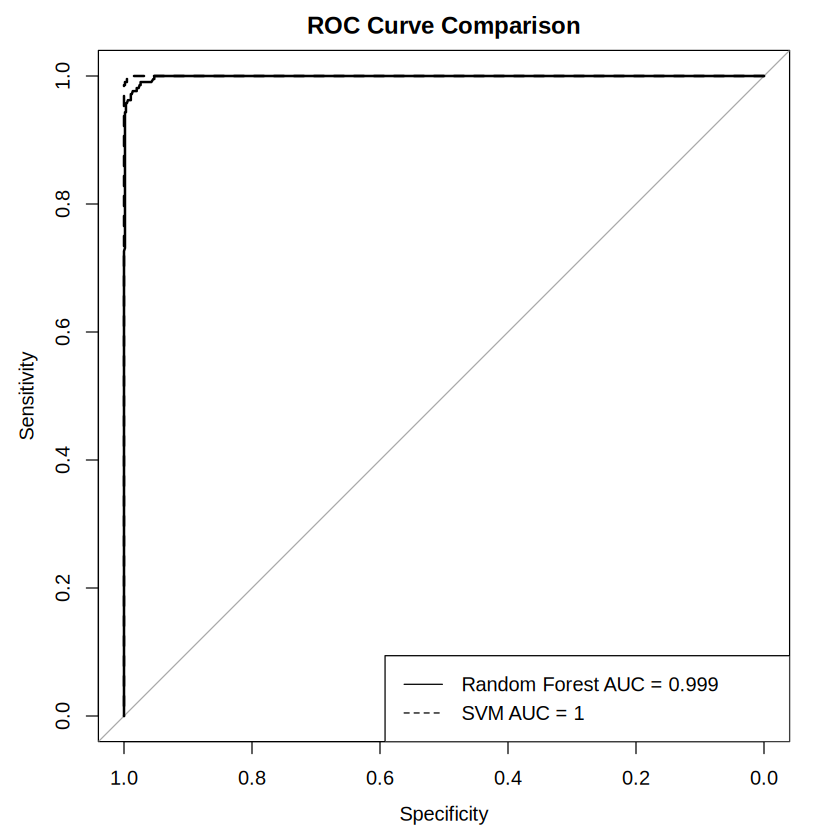

In [30]:
plot(
  rf_roc,
  main = "ROC Curve Comparison"
)

lines(
  svm_roc,
  lty = 2
)

legend(
  "bottomright",
  legend = c(
    paste("Random Forest AUC =", round(auc(rf_roc), 3)),
    paste("SVM AUC =", round(auc(svm_roc), 3))
  ),
  lty = c(1, 2)
)

19. Interactive 3D Plotly visualization

In [51]:
install.packages(c("plotly", "htmlwidgets", "IRdisplay"))
library(plotly)
library(htmlwidgets)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [52]:
library(plotly)

# Prepare 3D PCA data
pca3 <- data.frame(
  PC1 = pca$x[, 1],
  PC2 = pca$x[, 2],
  PC3 = pca$x[, 3],
  Cluster = as.factor(rfm$Cluster),
  CustomerID = rfm$CustomerID
)

# 3D interactive plot
fig <- plot_ly(
  data = pca3,
  x = ~PC1,
  y = ~PC2,
  z = ~PC3,
  color = ~Cluster,
  text = ~paste(
    "Customer ID:", CustomerID,
    "<br>Cluster:", Cluster
  ),
  type = "scatter3d",
  mode = "markers",
  marker = list(size = 4)
)

fig <- fig %>%
  layout(
    title = "3D Customer Segmentation",
    scene = list(
      xaxis = list(title = "PC1"),
      yaxis = list(title = "PC2"),
      zaxis = list(title = "PC3")
    )
  )

print(fig)

In [53]:
library(htmlwidgets)
library(IRdisplay)

saveWidget(fig, "pca3d.html", selfcontained = TRUE)
display_html(paste(readLines("pca3d.html"), collapse = "\n"))

<!DOCTYPE html>
 
 
 
 plotly

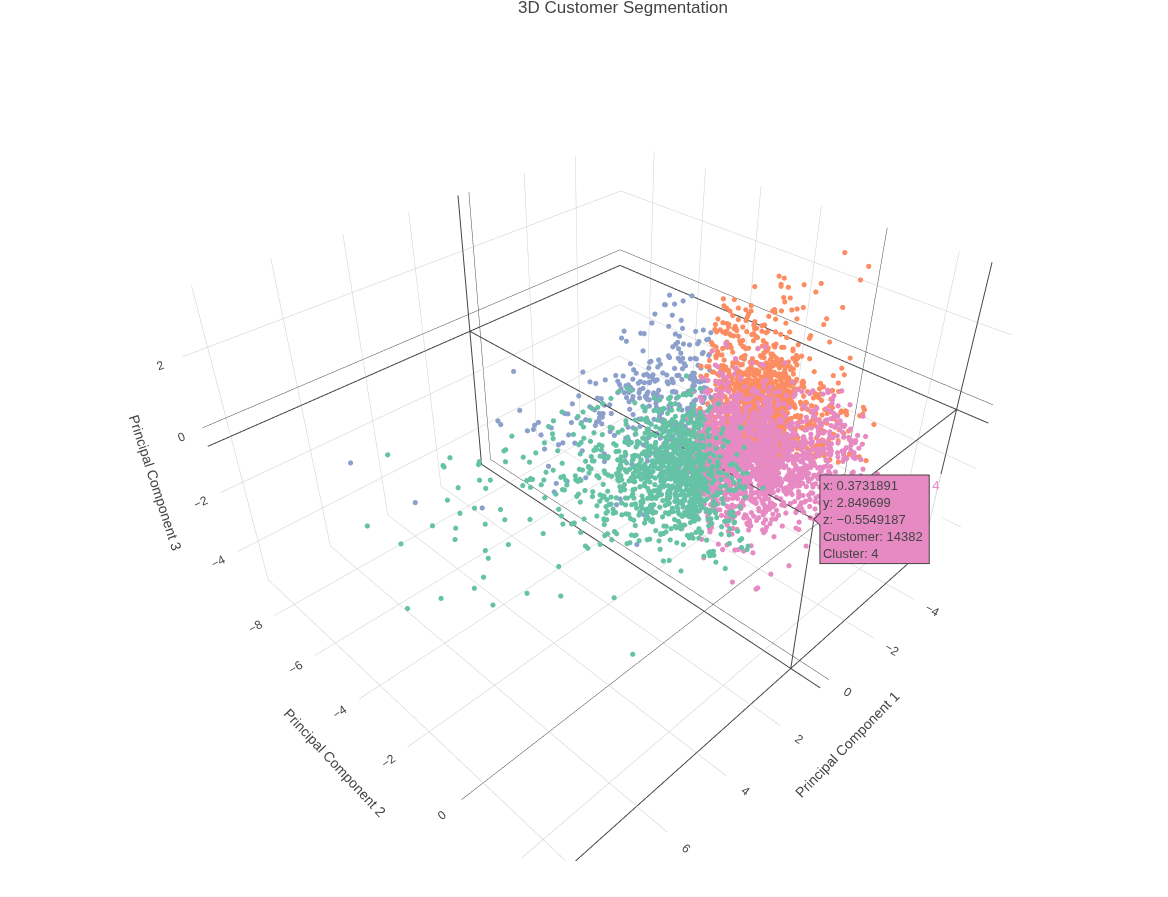